# Nearest-Neighbour Spacing Profile

Table 1's `mean_nearest_neighbour_distance` is a single number: an average over
every query's distance to its closest neighbour. An average can't tell you
*where the mass sits* -- a workload can post a healthy mean while a chunk of its
queries collapse onto near-duplicate plans, so long as the rest are spread far
enough apart to pull the average back up. This notebook is the full distribution
behind that one number: each query's distance to its nearest neighbour, sorted,
so a hidden duplication cluster shows up as a flat near-zero shelf instead of
disappearing into an average.

Computed on the same **weighted-Jaccard distance over plan-graph features**
(`loader/workload_analysis.py:plan_graph_feature_counter` +
`weighted_jaccard_similarity`) behind Table 1's Vendi score and
mean-nearest-neighbour-distance -- no projection, no PCA/UMAP, no
hyperparameters to second-guess.

Plan graphs come from each workload's already-captured `plans.json` (no Trino
round-trip needed unless one's missing), and the resulting feature records are
further cached to `results/embedding_records_cache.pkl` so re-running this
notebook doesn't even need to re-read/re-parse those. Delete the pickle cache
to force a rebuild from `plans.json`.

## 0 · Config

In [1]:
from pathlib import Path
from collections import Counter
from itertools import combinations
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis import resolve_workload_path, load_plans_file, capture_query_plans_for_set
from loader.workload_analysis import (
    dags_from_plan_bundle,
    plan_graph_feature_counter,
    weighted_jaccard_similarity,
)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

WORKLOAD_ROOT = Path("/mnt/primary/Main/Workloads")
CACHE_PATH = Path("results/embedding_records_cache.pkl")
CATALOG = "iceberg"
SCHEMA = "tpcds"
MAX_QUERIES_PER_WORKLOAD = 1000  # only matters on a plans.json miss -- EXPLAIN
                                  # is a live round-trip per query.
PLAN_WORKERS = 8  # concurrent Trino connections, only used if some workload
                   # has no plans.json yet -- see capture_query_plans_for_set(plan_workers=...)

REF   = "tpcds"
OURS  = ["gpt_generated_1000_tpcds_tokens_no_feedback", "gpt_generated_1000_tpcds_tokens"]
BASELINES = ["bootstrapping_lcm_1000_tokens_tpcds",  # alphabetical by display name
             "e2etune_1000_tokens_tpcds",
             "sql_factory_1000_tokens_tpcds",
             "sqlbarber_1000_tokens_tpcds",
             "sqlstorm_1000_tokens_tpcds"]
WORKLOADS = [REF] + BASELINES + OURS

PRETTY = {"tpcds": "TPC-DS (ref)",
          "gpt_generated_1000_tpcds_tokens": "DiverSQL (W/ Feedback)",
          "gpt_generated_1000_tpcds_tokens_no_feedback": "DiverSQL (W/O Feedback)",
          "sqlstorm_1000_tokens_tpcds": "SQLStorm", "sqlbarber_1000_tokens_tpcds": "SQLBarber",
          "sql_factory_1000_tokens_tpcds": "SQL-Factory", "e2etune_1000_tokens_tpcds": "E2ETune",
          "bootstrapping_lcm_1000_tokens_tpcds": "Bootstrapping-LCM"}

# Distinct colour per baseline -- NOT a uniform grey -- so the spacing-profile
# lines stay legible; TPC-DS reference is always the same neutral grey. The two
# "ours" variants share the orange family (same system, feedback on/off) at
# different lightness rather than two unrelated hues.
COL = {
    "tpcds": "#9ca3af",
    "bootstrapping_lcm_1000_tokens_tpcds": "#6366f1",  # indigo
    "e2etune_1000_tokens_tpcds":           "#059669",  # emerald
    "sql_factory_1000_tokens_tpcds":       "#0891b2",  # cyan
    "sqlbarber_1000_tokens_tpcds":         "#a855f7",  # violet
    "sqlstorm_1000_tokens_tpcds":          "#db2777",  # pink
    "gpt_generated_1000_tpcds_tokens":     "#ea580c",  # orange (ours, w/ feedback)
    "gpt_generated_1000_tpcds_tokens_no_feedback": "#f59e0b",  # amber (ours, w/o feedback)
}

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## 1 · Load plan-graph features (cached pickle, else each workload's plans.json)

Each query becomes a bag-of-features `Counter` (operator types, operator-pair
edges, operator 3-grams) via `plan_graph_feature_counter`. Three tiers, cheapest
first: the pickle cache (skips everything), each workload's already-captured
`<workload>/plans.json` (skips Trino -- this is the common case, since every
workload here has already had its plans captured), and only as a last resort a
live Trino fetch via `capture_query_plans_for_set(...)` for any workload that's
still missing a `plans.json`.

In [2]:
if CACHE_PATH.exists():
    with open(CACHE_PATH, "rb") as f:
        _cache = pickle.load(f)
    records, failures = _cache["records"], _cache["failures"]
    print(f"loaded {len(records)} cached records from {CACHE_PATH} "
          f"(max_queries_per_workload={_cache.get('max_queries_per_workload')})")

    _cached_workloads = {r["workload"] for r in records}
    _missing = [w for w in WORKLOADS if w not in _cached_workloads]
    if _missing:
        print(f"WARNING: cache doesn't cover {_missing} -- delete {CACHE_PATH} "
              "and re-run this cell to rebuild from plans.json / a live fetch.")
else:
    # Prefer each workload's already-captured plans.json over a live Trino
    # EXPLAIN pass -- capture_query_plans_for_set() only actually hits Trino
    # for a workload that's missing one (or has stale plans vs. its q*.sql).
    bundles = {w: load_plans_file(resolve_workload_path(w, WORKLOAD_ROOT)) for w in WORKLOADS}
    need_live = [w for w, b in bundles.items() if b is None]

    if need_live:
        print(f"no plans.json for {need_live} -- capturing live (plan_workers={PLAN_WORKERS})")
        from trino_stack.lakehouse import Lakehouse
        lh = Lakehouse.from_release(
            instance_name="lakehouse-g",
            namespace="pgr24james",
            sync_schemas=True,
            verbose=False,
        )
        capture_query_plans_for_set(
            need_live,
            workload_root=WORKLOAD_ROOT,
            lh=lh,
            catalog=CATALOG,
            schema=SCHEMA,
            plan_workers=PLAN_WORKERS,
        )
        for w in need_live:
            bundles[w] = load_plans_file(resolve_workload_path(w, WORKLOAD_ROOT))
    else:
        print(f"plans.json already present for all {len(WORKLOADS)} workloads -- no Trino needed")

    records, failures = [], []
    for w in WORKLOADS:
        plan_bundle = bundles[w]
        if plan_bundle is None:
            failures.append({"workload": w, "error": "no plans.json even after capture"})
            print(f"  {w}: FAILED (no plans.json)")
            continue
        dags = dags_from_plan_bundle(plan_bundle)
        items = list(dags.items())[:MAX_QUERIES_PER_WORKLOAD]
        for qname, dag in items:
            records.append({"workload": w, "query": qname,
                             "features": plan_graph_feature_counter(dag)})
        print(f"  {w}: {len(items)} query plans")

    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(CACHE_PATH, "wb") as f:
        pickle.dump({"records": records, "failures": failures,
                     "max_queries_per_workload": MAX_QUERIES_PER_WORKLOAD}, f)
    print(f"\ncached {len(records)} records -> {CACHE_PATH}")

if failures:
    print("failures:", failures)

meta = pd.DataFrame({"workload": [r["workload"] for r in records],
                      "query": [r["query"] for r in records]})
print(meta["workload"].value_counts().rename(index=PRETTY))

loaded 7099 cached records from results/embedding_records_cache.pkl (max_queries_per_workload=1000)
workload
Bootstrapping-LCM          1000
E2ETune                    1000
SQL-Factory                1000
SQLBarber                  1000
SQLStorm                   1000
DiverSQL (W/O Feedback)    1000
DiverSQL (W/ Feedback)     1000
TPC-DS (ref)                 99
Name: count, dtype: int64


## 2 · Pairwise plan-graph distance (weighted Jaccard)

The headline, citable spread number. Computed directly on the raw feature
`Counter`s using the exact same `weighted_jaccard_similarity` that Table 1's
Vendi score and mean-nearest-neighbour-distance are built from, so this number
is consistent with the rest of the paper's diversity claims. `O(n^2)` pairs; a
one-time cost that only needs re-running if the cached records change.

In [3]:
n = len(records)
counters = [r["features"] for r in records]
D = np.zeros((n, n), dtype=np.float32)  # distance = 1 - weighted Jaccard similarity

t0 = time.time()
total_pairs = n * (n - 1) // 2
for idx, (i, j) in enumerate(combinations(range(n), 2)):
    d = 1.0 - weighted_jaccard_similarity(counters[i], counters[j])
    D[i, j] = D[j, i] = d
    if idx % 500_000 == 0 and idx:
        elapsed = time.time() - t0
        print(f"  {idx:,}/{total_pairs:,} pairs ({elapsed:.0f}s elapsed, "
              f"~{elapsed / idx * total_pairs:.0f}s total est.)")

print(f"pairwise distance matrix done in {time.time() - t0:.0f}s")

  500,000/25,194,351 pairs (18s elapsed, ~889s total est.)
  1,000,000/25,194,351 pairs (35s elapsed, ~888s total est.)
  1,500,000/25,194,351 pairs (53s elapsed, ~891s total est.)
  2,000,000/25,194,351 pairs (71s elapsed, ~889s total est.)
  2,500,000/25,194,351 pairs (89s elapsed, ~893s total est.)
  3,000,000/25,194,351 pairs (106s elapsed, ~894s total est.)
  3,500,000/25,194,351 pairs (124s elapsed, ~894s total est.)
  4,000,000/25,194,351 pairs (142s elapsed, ~896s total est.)
  4,500,000/25,194,351 pairs (160s elapsed, ~896s total est.)
  5,000,000/25,194,351 pairs (178s elapsed, ~896s total est.)
  5,500,000/25,194,351 pairs (196s elapsed, ~897s total est.)
  6,000,000/25,194,351 pairs (214s elapsed, ~897s total est.)
  6,500,000/25,194,351 pairs (231s elapsed, ~897s total est.)
  7,000,000/25,194,351 pairs (249s elapsed, ~897s total est.)
  7,500,000/25,194,351 pairs (267s elapsed, ~898s total est.)
  8,000,000/25,194,351 pairs (286s elapsed, ~900s total est.)
  8,500,000/25,

## 3 · Nearest-neighbour spacing profile — does the mean hide duplicates?

Table 1's `mean_nearest_neighbour_distance` is an average over **all** pairs, so
it can't tell you *where* the mass sits. A workload can post a high mean while a
chunk of its queries collapse onto near-duplicate plans, as long as the rest are
spread far enough apart to pull the average back up — the all-pairs mean has no
concept of local density. That's exactly the profile SQLStorm shows: its
plan-graph uniqueness ratio is 0.790 (Table 1) yet its mean feature-space
distance is the highest of any workload.

The fix is to look at the **distribution of each query's distance to its single
closest neighbour**, sorted, rather than the one-number average. A generator
that guarantees separation shows a curve that lifts off from zero immediately;
a generator with hidden duplication shows a flat near-zero shelf on the low end
before the curve rises. This plot is that full distribution — Table 1's
`mean_nearest_neighbour_distance` is just its mean.

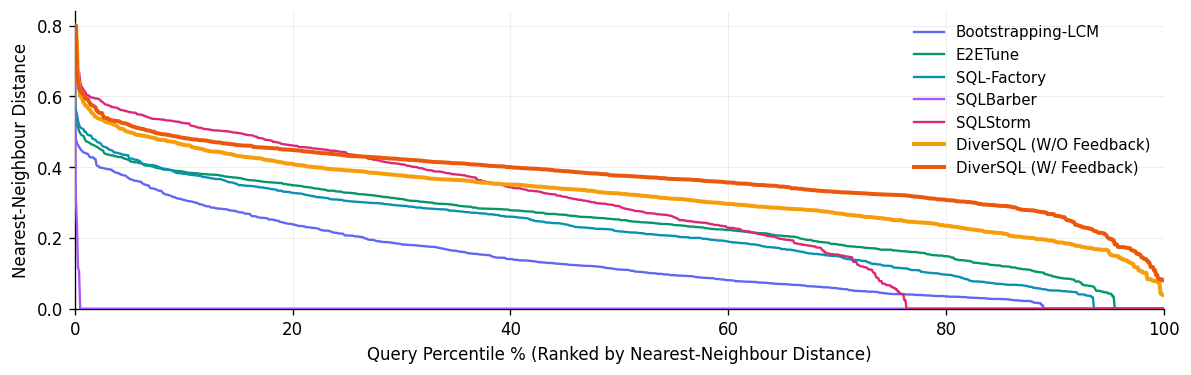

,Share of queries within 0.05 of a neighbour
SQLBarber,99.5%
Bootstrapping-LCM,27.8%
SQLStorm,24.5%
SQL-Factory,9.4%
E2ETune,5.8%
DiverSQL (W/O Feedback),0.4%
DiverSQL (W/ Feedback),0.0%


In [5]:
workload_idx = {w: [i for i, r in enumerate(records) if r["workload"] == w] for w in WORKLOADS}

def within_workload_nn_distances(w):
    """Each query's distance to its closest *other* query in the same workload."""
    idx = workload_idx[w]
    if len(idx) < 2:
        return np.array([])
    sub = D[np.ix_(idx, idx)].copy()
    np.fill_diagonal(sub, np.inf)
    return sub.min(axis=1)

EPS = 0.05  # "near-duplicate" threshold on weighted-Jaccard plan-graph distance
Axis_label_size = 10
# Drop the 99-query TPC-DS reference from the plot/table -- at n=99 its curve
# isn't a representative comparison point against 1,000-query generated sets.
PLOT_WORKLOADS = [w for w in WORKLOADS if w != REF]

fig, ax = plt.subplots(figsize=(10, 3.2))


dup_rates = {}
nn_sorted_by_workload = {}
for w in PLOT_WORKLOADS:
    nn = within_workload_nn_distances(w)
    if len(nn) == 0:
        continue
    # Sorted DESCENDING: x=0 (left) is each workload's most-isolated query,
    # x=100 (right) is its most-redundant one. 
    nn_sorted = np.sort(nn)[::-1]
    pct = np.linspace(0, 100, len(nn_sorted))
    lw = 2.4 if w in OURS else 1.4
    zorder = 5 if w in OURS else 3
    ax.plot(pct, nn_sorted, color=COL[w], lw=lw, zorder=zorder, label=PRETTY[w])
    dup_rates[w] = float((nn_sorted < EPS).mean())
    nn_sorted_by_workload[w] = nn_sorted

# Call out SQLBarber specifically: its collapse is so fast (>99% of queries
# land within EPS of a neighbour) that it happens in the first ~1% of the
# x-axis -- easy to misread as "starts near zero" instead of "instantly
# collapses" unless it's flagged directly.
SQLBARBER = "sqlbarber_1000_tokens_tpcds"
nn_sb = nn_sorted_by_workload[SQLBARBER]
pct_sb = np.linspace(0, 100, len(nn_sb))
cliff_i = int(np.argmax(nn_sb < EPS))  # first point that's dropped into near-duplicate territory
if False:
    ax.annotate(
        f"SQLBarber: {dup_rates[SQLBARBER]:.1%} of queries\nwithin {EPS} of a neighbour",
        xy=(pct_sb[cliff_i], nn_sb[cliff_i]), xycoords="data",
        xytext=(3, 0.08), textcoords="data",
        fontsize=9, fontweight="bold", color=COL[SQLBARBER],
        arrowprops=dict(arrowstyle="->", color=COL[SQLBARBER], lw=1.2,
                         connectionstyle="arc3,rad=-0"),
    )

ax.set_xlabel("Query Percentile % (Ranked by Nearest-Neighbour Distance)", fontsize=Axis_label_size)
ax.set_ylabel("Nearest-Neighbour Distance", fontsize=Axis_label_size)
ax.tick_params(axis='x', labelsize=Axis_label_size)
ax.tick_params(axis='y', labelsize=Axis_label_size)
ax.set_xlim(0, 100); ax.set_ylim(bottom=0)
ax.legend(fontsize=9, loc="upper right", frameon=False)

plt.savefig("./results/figures/collapse.pdf")
plt.savefig("./results/figures/collapse.png")
plt.tight_layout(); plt.show()

(pd.Series(dup_rates, name="pct")
   .rename(index=PRETTY)
   .sort_values(ascending=False)
   .to_frame(f"Share of queries within {EPS} of a neighbour")
   .style.format("{:.1%}"))
